# NB-01: データ探索・前処理

**目的**: めぐ指数パイプライン（NB-02 以降）の入力となる `megu_dataset.parquet` と `par_splits.parquet` を、page_reference の `race_result_flat` から組み立てる。

**実行順**: 上から順に全セルを実行する。後段は前段の DataFrame・列に依存する（特に §3 の `race_t2nd_sec` → §6 の基準前半スプリット）。

---

## データの流れ（中間テーブル）

| 段階 | DataFrame | 行の単位 | 馬場 | 備考 |
|------|-----------|----------|------|------|
| ロード後 | `df_raw` | 1頭 | 芝・ダート・障 | 全年結合（約31万行） |
| §2 抽出後 | `df_flat` | 1頭 | **芝・ダートのみ** | 障害除外 + `front_split_sec` マージ済み |
| §4 後 | `df_main` | 1頭 | 芝・ダート | 分析用列名・カテゴリ付与 |
| §5 後 | `df_clean` | 1頭 | 芝・ダート | タイム外れ値除去後（約30万行） |
| 保存 | `df_save` | 1頭 | 芝・ダート | `SAVE_COLS` のみ抽出 |

---

## セクション別の目的・処理・追加データ

### セットアップ（code）

- **目的**: ライブラリ読み込み、パス定義
- **処理**: `OUTPUT_DIR`・`TABLES_DIR`・`ALL_YEARS`（2020–2026）、日本語フォント
- **追加データ**: なし

---

### §1 生データロード → `df_raw`

- **目的**: 全年の出走結果を1テーブルに統合
- **入力**: `data/page_reference/tables/{year}/race_result_flat.parquet`
- **処理**: 必要列だけ読み込み、`year` 列を付与して `concat`
- **保持する元列（主）**:

| 列 | 内容 |
|----|------|
| `race_id`, `date`, `year` | レース識別・日付 |
| `venue`, `venue_code`, `direction` | 競馬場・コース方向 |
| `surface`, `distance` | 馬場（芝/ダート/障）・距離 |
| `grade`, `race_class`, `track_condition`, `weather`, `field_size` | クラス・馬場状態 |
| `horse_id`, `horse_number`, `sex_age`, `jockey_weight` | 馬・斤量 |
| `finish_position`, `time_sec`, `last_3f`, `lap_times`, `pace` | 着順・タイム・ラップ |

---

### 斤量補正（code）→ `df_raw` に列追加

- **目的**: 斤量差を走破タイムから除去した **分析用タイム** `adjusted_time_sec` を作る
- **処理**:
  - 5着以内・芝/ダート/障のレース内偏差で `surface×distance×性別` ごとに sec/kg を OLS 推定
  - 不足セルは `surface×性別` の距離スケールモデル → 理論値 0.2秒/kg@2000m
- **追加列**:

| 列 | 内容 |
|----|------|
| `finish_pos` | 着順（数値化） |
| `time_sec_num`, `distance_num`, `jockey_weight_num` | 数値化タイム・距離・斤量 |
| `sex`, `sex_group` | 性別（牡・セン→牡 / 牝） |
| `base_weight_kg` | 基準斤量（牡・セン55kg / 牝53kg） |
| `weight_dev_kg`, `weight_dev` | 斤量偏差（実斤量−基準） |
| `age_num` | 年齢（`sex_age` から抽出） |
| `dist_scale` | 距離/2000（斤量補正の距離スケール） |
| `weight_sec_per_kg` | 推定 sec/kg（セル別） |
| `weight_coef_source` | 係数の出所（`cell_sex_within_race` 等） |
| `delta_weight_sec` | 斤量によるタイム増分（秒） |
| **`adjusted_time_sec`** | **斤量補正後走破タイム**（以降の分析ベース） |

---

### §2 実測前半スプリット（code）→ `df_flat`

- **目的**: ラップから **実測** の前半タイムをレースごとに算出（基準値ではない）
- **処理**:
  - `df_raw` から芝・ダートのみ抽出 → `df_flat`
  - `lap_splits.py`: JRA ラップ刻み（200m 倍数 / 先頭 remainder）で区間化
  - レース距離の **50%に最も近い** 累積点の通過タイムを採用
  - レース単位で算出後、**同一セル内で** `df_flat` に `race_id` マージ
- **追加列**:

| 列 | 内容 |
|----|------|
| **`front_split_sec`** | 実測前半スプリット（秒） |
| **`split_point_m`** | 計測点の累積距離（m） |

---

### §3 馬場速度指数（code）→ `df_flat` に列追加

- **目的**: その日の馬場が基準より速い/遅いかを、2着補正タイムの乖離で推定
- **対象**: 芝・ダートのみ（**障害は指数・補正とも対象外**）
- **処理** (`track_speed.py`):
  - 学習期 2020–2024 の2着 `adjusted_time_sec` 平均を **基準2着タイム**（`venue×surface×distance×class_group`、不足時プール）
  - クラス区分: `未勝利` / `1-3勝` / `OP`
  - 日×競馬場×馬場（`surface`）でレース乖離を平均
- **追加列**:

| 列 | 内容 |
|----|------|
| `date_str` | 日付文字列（YYYY-MM-DD） |
| `class_group` | レースのクラス3区分 |
| `par_2nd_adj_sec` | 基準2着タイム（秒） |
| `par_pool_level` | 基準タイムのプール段階 |
| **`race_t2nd_sec`** | 当該レース2着の斤量補正後タイム（§6 でも使用） |
| `race_track_dev_sec` | レース単位乖離（2着−基準、**正=遅い馬場**） |
| `track_dev_sec` | 日×競馬場×馬場の平均乖離（秒） |
| **`tsi_raw`** | `-track_dev_sec`（**正=時計が出やすい**） |
| `n_races_track` | 当日集計に使ったレース数 |

- **中間テーブル**: `race_track_tbl`（レース単位）, `day_course_tbl`（日×競馬場×馬場）

---

### §4 マスターデータセット（code）→ `df_main`

- **目的**: 下流分析用の列名統一とカテゴリ付与
- **処理**: `df_main = df_flat.copy()`、タイム欠損・障害を除外
- **追加列**:

| 列 | 内容 |
|----|------|
| `finish_time_raw_sec` | 生走破タイム |
| **`finish_time_sec`** | 分析用タイム（= `adjusted_time_sec`） |
| `distance_band` | 距離帯（sprint/mile/middle/long） |
| `track_cat` | 馬場状態カテゴリ（良/稍重/重・不良） |

---

### §5 外れ値除去（code）→ `df_clean`

- **目的**: セル内で極端に遅い/速い斤量補正タイムを除外
- **処理**: `distance_band × surface × track_cat` ごとに z-score を計算し **|z|>3.5** を除去
- **追加列（除去判定用）**:

| 列 | 内容 |
|----|------|
| `time_mean`, `time_std`, `time_z` | セル内平均・標準偏差・z-score |

- **出力**: 外れ値行を除いた `df_clean`（`megu_dataset` の本体）

---

### §6 基準前半スプリット（code）→ `df_clean` + `par_split_full`

- **目的**: §2 の **実測** `front_split_sec` に対する **基準値** を推定（ペース補正用、NB-02）
- **処理** (`par_front_split.py` の `fit_par_front_split_coefficients` / `attach_par_front_split_sec`):
  - 学習: 2020–2024 の2着馬（`race_t2nd_sec` は §3 付与済み。**再マージしない**）
  - モデル: `front_split_sec ≈ intercept + slope × (race_t2nd_sec − t2nd_ref)`
  - セル `distance×surface`、n<30 は `surface` プール
- **`df_clean` に追加**:

| 列 | 内容 |
|----|------|
| `par_intercept`, `par_slope`, `t2nd_ref` | 連続モデル係数（マージ用） |
| **`par_front_split_sec`** | 当該レースの基準前半スプリット（秒） |

- **`par_split_full`（係数テーブル、別ファイル保存）**:

| 列 | 内容 |
|----|------|
| `distance`, `surface` | セルキー |
| `par_intercept`, `par_slope`, `t2nd_ref`, `n_fit`, `model` | 推定結果 |

---

### §7 保存（code）

- **出力ファイル**:

| ファイル | 内容 | 規模の目安 |
|----------|------|------------|
| `output/nb01/megu_dataset.parquet` | `df_clean` から `SAVE_COLS` を抽出 | 約30万行×33列 |
| `output/nb01/par_splits.parquet` | `par_split_full`（係数テーブル） | 約30セル |
| `output/nb01/data_distribution.png` | タイム・馬場乖離の分布プロット | — |
| `output/nb01/weight_explorer.html` | 斤量補正（馬場×性別×距離） | セル直下 iframe |
| `output/nb01/track_explorer.html` | 馬場速度指数（会場×馬場） | セル直下 iframe |
| `output/nb01/par_split_explorer.html` | 基準前半スプリット OLS | セル直下 iframe |
| `output/nb01/dataset_overview.html` | 保存データ分布概要 | セル直下 iframe |

- **`megu_dataset.parquet` の主な列（`SAVE_COLS`）**:

| グループ | 列 |
|----------|-----|
| キー・条件 | `race_id`, `date`, `year`, `venue`, `venue_code`, `surface`, `distance`, `distance_band`, `direction`, `grade`, `race_class`, `track_condition`, `track_cat`, `weather`, `field_size` |
| 馬 | `horse_id`, `horse_number`, `sex`, `age_num`, `jockey_weight_num`, `finish_pos` |
| タイム | `finish_time_raw_sec`, `finish_time_sec`, `adjusted_time_sec`, `last_3f` |
| ペース | `front_split_sec`, `split_point_m`, `race_t2nd_sec`, `par_front_split_sec` |
| 馬場指数 | `class_group`, `par_2nd_adj_sec`, `race_track_dev_sec`, `track_dev_sec`, `tsi_raw` |
| 斤量 | `weight_dev`, `dist_scale`, `weight_sec_per_kg`, `delta_weight_sec` |
| 品質 | `time_z` |

---

## 使用データソース

| データ | 取得元 |
|--------|--------|
| race_result_flat | `data/page_reference/tables/{year}/` |

## 下流での利用

| 出力 | 利用先 |
|------|--------|
| `megu_dataset.parquet` | NB-02（ペース係数）, NB-03（Δtrack）, NB-04（めぐ指数） |
| `par_splits.parquet` | NB-02, NB-03（`front_split_dev` 算出） |

**注**: 獲得賞金（Δlevel）は現 STG 未入力のため NB-04 以降で 0 扱い（FQ 枠組みは維持）。


In [16]:
import sys, json, warnings
sys.path.insert(0, '/home/jovyan/work/keiba-vpn')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path

_NB_DIR = Path('/home/jovyan/work/keiba-vpn/notebooks/megu_index')
if str(_NB_DIR) not in sys.path:
    sys.path.insert(0, str(_NB_DIR))

# 日本語フォント設定（matplotlib 3.x: addfont + FontProperties で明示登録）
plt.rcParams['axes.unicode_minus'] = False
_JP_FONT_CANDIDATES = [
    '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',
    '/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc',
]
_jp_font_path = next((p for p in _JP_FONT_CANDIDATES if Path(p).exists()), None)
if _jp_font_path:
    fm.fontManager.addfont(_jp_font_path)
    _jp_font_name = fm.FontProperties(fname=_jp_font_path).get_name()
    plt.rcParams['font.family'] = _jp_font_name
    plt.rcParams['font.sans-serif'] = [_jp_font_name, 'DejaVu Sans']
    print(f'日本語フォント: {_jp_font_name}')
else:
    print('WARNING: 日本語フォント未検出。`sudo apt-get install -y fonts-noto-cjk` を実行してください。')

OUTPUT_DIR = Path('/home/jovyan/work/keiba-vpn/notebooks/megu_index/output/nb01')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR = Path('/home/jovyan/work/keiba-vpn/data/page_reference/tables')
ALL_YEARS = [str(y) for y in range(2020, 2027)]

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
print('Setup OK')


日本語フォント: Noto Sans CJK JP
Setup OK


## 1. race_result_flat 全年ロード

In [17]:
# ── 全年 race_result_flat ロード ────────────────────────────────────────
KEEP_COLS = [
    'race_id', 'date', 'venue', 'venue_code', 'surface', 'distance',
    'direction', 'grade', 'race_class', 'weather', 'track_condition',
    'field_size', 'race_name',
    # 馬
    'horse_id', 'horse_number', 'sex_age', 'jockey_weight',
    # タイム・ラップ
    'finish_position', 'time_sec', 'last_3f', 'lap_times', 'pace',
]

parts = []
for year in ALL_YEARS:
    p = TABLES_DIR / year / 'race_result_flat.parquet'
    if not p.exists():
        print(f'SKIP {year}: not found')
        continue
    cols = [c for c in KEEP_COLS if c in pd.read_parquet(p, engine='pyarrow').columns]
    df_y = pd.read_parquet(p, columns=cols)
    df_y['year'] = int(year)
    parts.append(df_y)
    print(f'{year}: {len(df_y):,} 行')

df_raw = pd.concat(parts, ignore_index=True)
print(f'\n合計: {len(df_raw):,} 行  期間: {df_raw["date"].min()} 〜 {df_raw["date"].max()}')
print(f'surface分布:', df_raw['surface'].value_counts().to_dict())


2020: 48,282 行
2021: 47,821 行
2022: 47,220 行
2023: 47,672 行
2024: 47,181 行
2025: 47,884 行
2026: 25,277 行

合計: 311,337 行  期間: 2020-01-05 〜 2026-07-05
surface分布: {'ダート': 155013, '芝': 149776, '障': 2133}


### データ確認

In [18]:
df_raw

,race_id,date,venue,venue_code,surface,distance,direction,grade,race_class,weather,track_condition,field_size,race_name,horse_id,horse_number,sex_age,jockey_weight,finish_position,time_sec,last_3f,lap_times,pace,year
0,202001010101,2020-07-25,札幌,01,芝,1800,右,未勝利,サラ系２歳 未勝利,曇,良,6,2歳未勝利,2018101626,6,牝2,54.0000,1,109.7000,35.6000,"[12.4, 11.3, 12.4, 12.7, 12.8, 12.2, 12.0, 11....","{""first_half_3f"": 36.1, ""second_half_3f"": 35.9...",2020
1,202001010101,2020-07-25,札幌,01,芝,1800,右,未勝利,サラ系２歳 未勝利,曇,良,6,2歳未勝利,2018105193,2,牡2,54.0000,2,110.0000,35.8000,"[12.4, 11.3, 12.4, 12.7, 12.8, 12.2, 12.0, 11....","{""first_half_3f"": 36.1, ""second_half_3f"": 35.9...",2020
2,202001010101,2020-07-25,札幌,01,芝,1800,右,未勝利,サラ系２歳 未勝利,曇,良,6,2歳未勝利,2018104800,3,牡2,54.0000,3,110.1000,36.2000,"[12.4, 11.3, 12.4, 12.7, 12.8, 12.2, 12.0, 11....","{""first_half_3f"": 36.1, ""second_half_3f"": 35.9...",2020
3,202001010101,2020-07-25,札幌,01,芝,1800,右,未勝利,サラ系２歳 未勝利,曇,良,6,2歳未勝利,2018102410,1,牝2,52.0000,4,110.5000,36.7000,"[12.4, 11.3, 12.4, 12.7, 12.8, 12.2, 12.0, 11....","{""first_half_3f"": 36.1, ""second_half_3f"": 35.9...",2020
4,202001010101,2020-07-25,札幌,01,芝,1800,右,未勝利,サラ系２歳 未勝利,曇,良,6,2歳未勝利,2018100828,4,牡2,54.0000,5,111.0000,36.6000,"[12.4, 11.3, 12.4, 12.7, 12.8, 12.2, 12.0, 11....","{""first_half_3f"": 36.1, ""second_half_3f"": 35.9...",2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
311332,202610020412,2026-07-05,小倉,10,None,0,None,1勝,None,小雨,不良,16,3歳以上1勝クラス,2023102380,11,牡3,53.0000,12,105.2000,38.9000,"[7.0, 10.7, 11.4, 12.1, 11.9, 12.0, 12.4, 12.6...","{""first_half_3f"": 29.1, ""second_half_3f"": 37.3...",2026
311333,202610020412,2026-07-05,小倉,10,None,0,None,1勝,None,小雨,不良,16,3歳以上1勝クラス,2022102839,14,牡4,58.0000,13,105.5000,38.0000,"[7.0, 10.7, 11.4, 12.1, 11.9, 12.0, 12.4, 12.6...","{""first_half_3f"": 29.1, ""second_half_3f"": 37.3...",2026
311334,202610020412,2026-07-05,小倉,10,None,0,None,1勝,None,小雨,不良,16,3歳以上1勝クラス,2022106663,12,牝4,56.0000,14,105.7000,39.3000,"[7.0, 10.7, 11.4, 12.1, 11.9, 12.0, 12.4, 12.6...","{""first_half_3f"": 29.1, ""second_half_3f"": 37.3...",2026
311335,202610020412,2026-07-05,小倉,10,None,0,None,1勝,None,小雨,不良,16,3歳以上1勝クラス,2022102998,13,牝4,56.0000,15,106.2000,39.9000,"[7.0, 10.7, 11.4, 12.1, 11.9, 12.0, 12.4, 12.6...","{""first_half_3f"": 29.1, ""second_half_3f"": 37.3...",2026


### 斤量補正後タイム（adjusted_time_sec）

- 基準斤量: 牡・セン **55kg**、牝 **53kg**
- **5着以内**のデータで、**芝 / ダート / 障害 × 距離 × 性別（牡・セン / 牝）** ごとに「斤量1kgあたりのタイム増分（秒/kg）」を推定
- 推定は **レース内偏差**（同一レース内での斤量差とタイム差）を用い、能力の交絡を抑える
- フォールバック: `surface × sex` の距離スケールモデル → 理論値 **0.2秒/kg@2000m**

In [19]:
# ── 斤量補正後タイム (adjusted_time_sec) ───────────────────────────────
MIN_SAMPLES = 30
THEORY_BETA_AT_2000M = 0.2  # NB-03 理論値: 2000m で 0.2 秒/kg
MAX_SEC_PER_KG = 0.5

df_raw['finish_pos'] = pd.to_numeric(df_raw['finish_position'], errors='coerce')
df_raw['time_sec_num'] = pd.to_numeric(df_raw['time_sec'], errors='coerce')
df_raw['distance_num'] = pd.to_numeric(df_raw['distance'], errors='coerce')
df_raw['jockey_weight_num'] = pd.to_numeric(df_raw['jockey_weight'], errors='coerce')

df_raw['sex'] = df_raw['sex_age'].astype(str).str.extract(r'^(牡|牝|セン)', expand=False).fillna('牡')
# 係数推定は牡・セン vs 牝で分ける（センは牡側に統合）
df_raw['sex_group'] = np.where(df_raw['sex'] == '牝', '牝', '牡')
df_raw['base_weight_kg'] = np.where(df_raw['sex_group'] == '牝', 53.0, 55.0)
df_raw['weight_dev_kg'] = df_raw['jockey_weight_num'] - df_raw['base_weight_kg']
df_raw['weight_dev'] = df_raw['weight_dev_kg']  # megu_dataset 出力名（下流 NB-02 等）
df_raw['age_num'] = pd.to_numeric(df_raw['sex_age'].astype(str).str.extract(r'(\d+)$', expand=False), errors='coerce')
df_raw['dist_scale'] = df_raw['distance_num'] / 2000.0
df_raw['weight_x_dist'] = df_raw['weight_dev_kg'] * df_raw['dist_scale']


def _ols_slope(x: np.ndarray, y: np.ndarray) -> float:
    if len(x) < MIN_SAMPLES or np.nanvar(x) < 1e-9:
        return np.nan
    return float(np.cov(x, y, bias=True)[0, 1] / np.var(x))


def _clip_sec_per_kg(v: float, dist: float) -> float:
    if pd.isna(v) or v <= 0:
        return THEORY_BETA_AT_2000M * dist / 2000.0
    return float(min(v, MAX_SEC_PER_KG))


mask_fit = (
    df_raw['finish_pos'].between(1, 5)
    & df_raw['time_sec_num'].notna()
    & df_raw['jockey_weight_num'].notna()
    & df_raw['surface'].isin(['芝', 'ダート', '障'])
    & df_raw['distance_num'].notna()
    & (df_raw['distance_num'] > 0)
)
df_fit = df_raw.loc[
    mask_fit,
    ['race_id', 'surface', 'distance_num', 'sex_group', 'weight_dev_kg', 'weight_x_dist', 'time_sec_num'],
].copy()

df_fit['time_dm'] = df_fit['time_sec_num'] - df_fit.groupby('race_id')['time_sec_num'].transform('mean')
df_fit['weight_dev_dm'] = df_fit['weight_dev_kg'] - df_fit.groupby('race_id')['weight_dev_kg'].transform('mean')
df_fit['weight_x_dist_dm'] = df_fit['weight_x_dist'] - df_fit.groupby('race_id')['weight_x_dist'].transform('mean')

# (A) surface × distance × sex_group
coef_rows = []
for (surf, dist, sex_g), g in df_fit.groupby(['surface', 'distance_num', 'sex_group'], sort=False):
    beta_direct = _ols_slope(g['weight_dev_dm'].to_numpy(), g['time_dm'].to_numpy())
    coef_rows.append({
        'surface': surf,
        'distance_num': int(dist),
        'sex_group': sex_g,
        'sec_per_kg_direct': _clip_sec_per_kg(beta_direct, dist) if beta_direct > 0 else np.nan,
        'n_fit': len(g),
    })
coef_by_cell = pd.DataFrame(coef_rows)

# (B) surface × sex_group フォールバック
surf_sex_beta: dict[tuple[str, str], float] = {}
for (surf, sex_g), g in df_fit.groupby(['surface', 'sex_group']):
    beta_wxd = _ols_slope(g['weight_x_dist_dm'].to_numpy(), g['time_dm'].to_numpy())
    surf_sex_beta[(surf, sex_g)] = beta_wxd if pd.notna(beta_wxd) and beta_wxd > 0 else THEORY_BETA_AT_2000M

coef_by_cell['beta_weight_surface_sex'] = coef_by_cell.apply(
    lambda r: surf_sex_beta.get((r['surface'], r['sex_group']), THEORY_BETA_AT_2000M), axis=1,
)
coef_by_cell['sec_per_kg_surface_dist'] = np.minimum(
    coef_by_cell['beta_weight_surface_sex'] * (coef_by_cell['distance_num'] / 2000.0),
    MAX_SEC_PER_KG,
)

coef_by_cell['sec_per_kg_final'] = coef_by_cell['sec_per_kg_direct'].fillna(coef_by_cell['sec_per_kg_surface_dist'])
coef_by_cell['weight_coef_source'] = np.where(
    coef_by_cell['sec_per_kg_direct'].notna(), 'cell_sex_within_race', 'surface_sex_within_race',
)

df_raw = df_raw.merge(
    coef_by_cell[['surface', 'distance_num', 'sex_group', 'sec_per_kg_final', 'weight_coef_source', 'n_fit']],
    on=['surface', 'distance_num', 'sex_group'],
    how='left',
)
df_raw.rename(columns={'sec_per_kg_final': 'weight_sec_per_kg', 'n_fit': 'weight_coef_n_fit'}, inplace=True)

df_raw['weight_sec_per_kg'] = df_raw['weight_sec_per_kg'].fillna(THEORY_BETA_AT_2000M * df_raw['dist_scale'])
df_raw['weight_coef_source'] = df_raw['weight_coef_source'].fillna('theory')

df_raw['delta_weight_sec'] = df_raw['weight_dev_kg'] * df_raw['weight_sec_per_kg']
df_raw['adjusted_time_sec'] = df_raw['time_sec_num'] - df_raw['delta_weight_sec']

print('斤量補正係数 sec_per_kg（surface×distance×sex）:')
print(coef_by_cell.groupby(['surface', 'sex_group'])['sec_per_kg_final'].agg(['count', 'median', 'mean']).round(4))
print('\n係数ソース:')
print(df_raw['weight_coef_source'].value_counts())
print(f"\nadjusted_time_sec カバレッジ: {df_raw['adjusted_time_sec'].notna().mean():.1%}")

for sex_g in ['牡', '牝']:
    ex = coef_by_cell[(coef_by_cell['surface'] == '芝') & (coef_by_cell['distance_num'] == 1800) & (coef_by_cell['sex_group'] == sex_g)]
    if len(ex):
        r = ex.iloc[0]
        print(f"芝1800m {sex_g}: sec_per_kg={r['sec_per_kg_final']:.4f} ({r['weight_coef_source']}, n={int(r['n_fit'])})")

df_raw

# ── インタラクティブ可視化（このセル直下に表示）────────────────────────────
from nb_viz import load_build_script, display_interactive_html

_nb01_viz = load_build_script('build_nb01_viz_html')
_weight_html = OUTPUT_DIR / 'weight_explorer.html'
_nb01_viz.write_weight_explorer_html(df_fit, coef_by_cell, _weight_html)
display_interactive_html(_weight_html, height=720, title='斤量補正エクスプローラ（馬場・性別・距離を選択）')


斤量補正係数 sec_per_kg（surface×distance×sex）:
                   count  median   mean
surface sex_group                      
ダート     牝             19  0.0179 0.0247
        牡             21  0.1400 0.1468
芝       牝             24  0.2150 0.1968
        牡             31  0.2770 0.2343
障       牝              5  0.3170 0.2780
        牡              8  0.3210 0.2927

係数ソース:
weight_coef_source
surface_sex_within_race    209541
cell_sex_within_race        97361
theory                       4435
Name: count, dtype: int64

adjusted_time_sec カバレッジ: 100.0%
芝1800m 牡: sec_per_kg=0.1800 (surface_sex_within_race, n=5501)
芝1800m 牝: sec_per_kg=0.1800 (surface_sex_within_race, n=4352)


,race_id,date,venue,venue_code,surface,distance,direction,grade,race_class,weather,track_condition,field_size,race_name,horse_id,horse_number,sex_age,jockey_weight,finish_position,time_sec,last_3f,lap_times,pace,year,finish_pos,time_sec_num,distance_num,jockey_weight_num,sex,sex_group,base_weight_kg,weight_dev_kg,weight_dev,age_num,dist_scale,weight_x_dist,weight_sec_per_kg,weight_coef_source,weight_coef_n_fit,delta_weight_sec,adjusted_time_sec
0,202001010101,2020-07-25,札幌,01,芝,1800,右,未勝利,サラ系２歳 未勝利,曇,良,6,2歳未勝利,2018101626,6,牝2,54.0000,1,109.7000,35.6000,"[12.4, 11.3, 12.4, 12.7, 12.8, 12.2, 12.0, 11....","{""first_half_3f"": 36.1, ""second_half_3f"": 35.9...",2020,1,109.7000,1800,54.0000,牝,牝,53.0000,1.0000,1.0000,2,0.9000,0.9000,0.1800,surface_sex_within_race,4352.0000,0.1800,109.5200
1,202001010101,2020-07-25,札幌,01,芝,1800,右,未勝利,サラ系２歳 未勝利,曇,良,6,2歳未勝利,2018105193,2,牡2,54.0000,2,110.0000,35.8000,"[12.4, 11.3, 12.4, 12.7, 12.8, 12.2, 12.0, 11....","{""first_half_3f"": 36.1, ""second_half_3f"": 35.9...",2020,2,110.0000,1800,54.0000,牡,牡,55.0000,-1.0000,-1.0000,2,0.9000,-0.9000,0.1800,surface_sex_within_race,5501.0000,-0.1800,110.1800
2,202001010101,2020-07-25,札幌,01,芝,1800,右,未勝利,サラ系２歳 未勝利,曇,良,6,2歳未勝利,2018104800,3,牡2,54.0000,3,110.1000,36.2000,"[12.4, 11.3, 12.4, 12.7, 12.8, 12.2, 12.0, 11....","{""first_half_3f"": 36.1, ""second_half_3f"": 35.9...",2020,3,110.1000,1800,54.0000,牡,牡,55.0000,-1.0000,-1.0000,2,0.9000,-0.9000,0.1800,surface_sex_within_race,5501.0000,-0.1800,110.2800
3,202001010101,2020-07-25,札幌,01,芝,1800,右,未勝利,サラ系２歳 未勝利,曇,良,6,2歳未勝利,2018102410,1,牝2,52.0000,4,110.5000,36.7000,"[12.4, 11.3, 12.4, 12.7, 12.8, 12.2, 12.0, 11....","{""first_half_3f"": 36.1, ""second_half_3f"": 35.9...",2020,4,110.5000,1800,52.0000,牝,牝,53.0000,-1.0000,-1.0000,2,0.9000,-0.9000,0.1800,surface_sex_within_race,4352.0000,-0.1800,110.6800
4,202001010101,2020-07-25,札幌,01,芝,1800,右,未勝利,サラ系２歳 未勝利,曇,良,6,2歳未勝利,2018100828,4,牡2,54.0000,5,111.0000,36.6000,"[12.4, 11.3, 12.4, 12.7, 12.8, 12.2, 12.0, 11....","{""first_half_3f"": 36.1, ""second_half_3f"": 35.9...",2020,5,111.0000,1800,54.0000,牡,牡,55.0000,-1.0000,-1.0000,2,0.9000,-0.9000,0.1800,surface_sex_within_race,5501.0000,-0.1800,111.1800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
311332,202610020412,2026-07-05,小倉,10,None,0,None,1勝,None,小雨,不良,16,3歳以上1勝クラス,2023102380,11,牡3,53.0000,12,105.2000,38.9000,"[7.0, 10.7, 11.4, 12.1, 11.9, 12.0, 12.4, 12.6...","{""first_half_3f"": 29.1, ""second_half_3f"": 37.3...",2026,12,105.2000,0,53.0000,牡,牡,55.0000,-2.0000,-2.0000,3,0.0000,-0.0000,0.0000,theory,NaN,-0.0000,105.2000
311333,202610020412,2026-07-05,小倉,10,None,0,None,1勝,None,小雨,不良,16,3歳以上1勝クラス,2022102839,14,牡4,58.0000,13,105.5000,38.0000,"[7.0, 10.7, 11.4, 12.1, 11.9, 12.0, 12.4, 12.6...","{""first_half_3f"": 29.1, ""second_half_3f"": 37.3...",2026,13,105.5000,0,58.0000,牡,牡,55.0000,3.0000,3.0000,4,0.0000,0.0000,0.0000,theory,NaN,0.0000,105.5000
311334,202610020412,2026-07-05,小倉,10,None,0,None,1勝,None,小雨,不良,16,3歳以上1勝クラス,2022106663,12,牝4,56.0000,14,105.7000,39.3000,"[7.0, 10.7, 11.4, 12.1, 11.9, 12.0, 12.4, 12.6...","{""first_half_3f"": 29.1, ""second_half_3f"": 37.3...",2026,14,105.7000,0,56.0000,牝,牝,53.0000,3.0000,3.0000,4,0.0000,0.0000,0.0000,theory,NaN,0.0000,105.7000
311335,202610020412,2026-07-05,小倉,10,None,0,None,1勝,None,小雨,不良,16,3歳以上1勝クラス,2022102998,13,牝4,56.0000,15,106.2000,39.9000,"[7.0, 10.7, 11.4, 12.1, 11.9, 12.0, 12.4, 12.6...","{""first_half_3f"": 29.1, ""second_half_3f"": 37.3...",2026,15,106.2000,0,56.0000,牝,牝,53.0000,3.0000,3.0000,4,0.0000,0.0000,0.0000,theory,NaN,0.0000,106.2000


## 2. 前半スプリットタイム計算（実測）

ラップから **実測** `front_split_sec` を算出し `df_flat` にマージする（基準値 `par_front_split` は §6）。

- ラップ区間長: 200m 倍数なら全区間 200m／それ以外は先頭 `distance%200`（100m・150m 等）+ 以降 200m（300m 先頭はラップ数一致時）
- 計測点: レース距離の **50%に最も近い** 累積距離点（同距離差は中間以下を優先）

In [20]:
from src.pipeline.megu_index.lap_splits import parse_lap_times, select_split_point

# ── スプリット計算 ──────────────────────────────────────────────────────
print('前半スプリット計算中...')
df_flat = df_raw[df_raw['surface'].isin(['芝', 'ダート']) & df_raw['distance'].notna()].copy()
df_flat['distance'] = pd.to_numeric(df_flat['distance'], errors='coerce')
df_flat = df_flat[df_flat['distance'] > 0]

splits = []
for _, row in df_flat[['race_id','distance','lap_times']].drop_duplicates('race_id').iterrows():
    lap_dict = parse_lap_times(row['lap_times'], row['distance'])
    if not lap_dict:
        splits.append({'race_id': row['race_id'], 'front_split_sec': np.nan, 'split_point_m': np.nan})
        continue
    sp = select_split_point(int(row['distance']), list(lap_dict.keys()))
    if sp is None:
        splits.append({'race_id': row['race_id'], 'front_split_sec': np.nan, 'split_point_m': np.nan})
    else:
        splits.append({'race_id': row['race_id'], 'front_split_sec': lap_dict[sp], 'split_point_m': int(sp)})

df_splits = pd.DataFrame(splits)
print(f'スプリット計算: {len(df_splits):,} レース')
print(f'front_split_sec カバレッジ: {df_splits["front_split_sec"].notna().mean():.1%}')
print(f'split_point_m 分布:')
print(df_splits['split_point_m'].value_counts().head(10).to_dict())


前半スプリット計算中...
スプリット計算: 22,041 レース
front_split_sec カバレッジ: 97.1%
split_point_m 分布:
{800.0: 7788, 600.0: 6957, 1000.0: 2823, 900.0: 1598, 1200.0: 776, 400.0: 569, 700.0: 272, 1100.0: 255, 550.0: 216, 1300.0: 98}


In [21]:
df_splits

,race_id,front_split_sec,split_point_m
0,202001010101,48.8000,800.0000
1,202001010102,54.8000,900.0000
2,202001010103,41.6000,700.0000
3,202001010104,55.9000,900.0000
4,202001010105,35.6000,600.0000
...,...,...,...
22036,202610020405,51.0000,800.0000
22037,202610020407,33.1000,600.0000
22038,202610020408,60.6000,1000.0000
22039,202610020409,48.1000,800.0000


## 3. 馬場速度指数（基準2着タイムとの乖離）

- **対象**: 芝・ダートのみ。**障害レースは馬場の速さによる補正を行わない**（基準タイム推定・乖離計算・`tsi_raw` 付与のいずれも対象外。NB-01 以降のめぐ指数パイプラインでも障害は除外）
- **グループ**: 日 × 競馬場 × 馬場（`surface`）
- **基準タイム**: 学習期（2020–2024）の **2着馬 `adjusted_time_sec` 平均**（`venue×surface×distance×class_group`、不足時は `surface×distance×class_group` へプール）
- **クラス区分**: 未勝利（未勝利・新馬）/ 1-3勝 / OP（OP・L・重賞）
- **指標**: `race_track_dev_sec` = 当該レース2着 − 基準（秒、**正=遅い**）→ 日×競馬場×馬場で平均 → `track_dev_sec` / `tsi_raw`（= −平均、**正=時計出やすい**）

In [22]:
from src.pipeline.megu_index.track_speed import attach_track_speed_to_horses

# ── 馬場速度指数（基準2着タイムとの乖離）────────────────────────────────
TRAIN_YEARS_TRACK = [2020, 2021, 2022, 2023, 2024]
MIN_PAR_SAMPLES = 30

df_flat, race_track_tbl, day_course_tbl = attach_track_speed_to_horses(
    df_flat,
    train_years=TRAIN_YEARS_TRACK,
    min_samples=MIN_PAR_SAMPLES,
)

print(f'レース単位 track dev カバレッジ: {df_flat["race_track_dev_sec"].notna().mean():.1%}')
print(f'日×コース track_dev_sec カバレッジ: {df_flat["track_dev_sec"].notna().mean():.1%}')
print(f'tsi_raw (= -track_dev_sec) カバレッジ: {df_flat["tsi_raw"].notna().mean():.1%}')
print(f'\nクラス区分分布:')
print(df_flat['class_group'].value_counts().to_dict())
print(f'\nrace_track_dev_sec（秒, 正=基準より遅い）:')
print(df_flat['race_track_dev_sec'].describe())
print(f'\ntrack_dev_sec（日×コース平均）:')
print(df_flat['track_dev_sec'].describe())
print(f'\n日×コース集計: {len(day_course_tbl):,} 行')

slow_top = day_course_tbl.nlargest(3, 'track_dev_sec')[
    ['date_str', 'venue', 'surface', 'track_dev_sec', 'tsi_raw', 'n_races_track']
]
print('\n遅め馬場トップ3:')
print(slow_top.to_string(index=False))

# ── インタラクティブ可視化（このセル直下に表示）────────────────────────────
from nb_viz import load_build_script, display_interactive_html

_nb01_viz = load_build_script('build_nb01_viz_html')
_track_html = OUTPUT_DIR / 'track_explorer.html'
_nb01_viz.write_track_explorer_html(day_course_tbl, _track_html)
display_interactive_html(_track_html, height=620, title='馬場速度指数エクスプローラ（会場・馬場を選択）')


レース単位 track dev カバレッジ: 97.7%
日×コース track_dev_sec カバレッジ: 100.0%
tsi_raw (= -track_dev_sec) カバレッジ: 100.0%

クラス区分分布:
{'1-3勝': 139001, '未勝利': 138244, 'OP': 27544}

race_track_dev_sec（秒, 正=基準より遅い）:
count   297709.0000
mean        -0.1333
std          1.2832
min         -5.4718
25%         -0.9059
50%         -0.1602
75%          0.5968
max          8.4659
Name: race_track_dev_sec, dtype: float64

track_dev_sec（日×コース平均）:
count   304739.0000
mean        -0.0915
std          0.9632
min         -3.5609
25%         -0.7102
50%         -0.0761
75%          0.4846
max          5.8782
Name: track_dev_sec, dtype: float64

日×コース集計: 3,717 行

遅め馬場トップ3:
  date_str venue surface  track_dev_sec  tsi_raw  n_races_track
2026-03-29    阪神     ダート         5.8782  -5.8782              1
2020-04-18    中山       芝         5.8223  -5.8223              4
2021-04-18    新潟       芝         5.6189  -5.6189              3


In [23]:
day_course_tbl

,date_str,venue,surface,track_dev_sec,n_races_track,tsi_raw
0,2020-01-05,中山,ダート,0.6415,7,-0.6415
1,2020-01-05,中山,芝,-0.3962,5,0.3962
2,2020-01-05,京都,ダート,0.1109,7,-0.1109
3,2020-01-05,京都,芝,2.0111,5,-2.0111
4,2020-01-06,中山,ダート,0.7055,8,-0.7055
...,...,...,...,...,...,...
3712,2026-07-04,小倉,芝,0.0345,8,-0.0345
3713,2026-07-04,福島,芝,-2.0607,6,2.0607
3714,2026-07-05,函館,芝,-1.1791,7,1.1791
3715,2026-07-05,小倉,芝,0.6247,8,-0.6247


## 4. 斤量偏差（weight_dev）の計算

In [24]:
# ── 斤量偏差 ──────────────────────────────────────────────────────────
# 基準: 牡・セン = 55kg, 牝 = 53kg（斤量補正セルと同一）
# weight_dev は補正セルで算出済みなら流用

if 'sex' not in df_flat.columns or df_flat['sex'].isna().all():
    df_flat['sex'] = df_flat['sex_age'].str.extract(r'^(牡|牝|セン)', expand=False).fillna('牡')
df_flat['age_num'] = pd.to_numeric(df_flat['sex_age'].str.extract(r'(\d+)$', expand=False), errors='coerce')

if 'weight_dev_kg' in df_flat.columns:
    df_flat['weight_dev'] = df_flat['weight_dev_kg']
else:
    df_flat['base_weight'] = np.where(df_flat['sex'] == '牝', 53.0, 55.0)
    df_flat['jockey_weight_num'] = pd.to_numeric(df_flat['jockey_weight'], errors='coerce')
    df_flat['weight_dev'] = df_flat['jockey_weight_num'] - df_flat['base_weight']

if 'dist_scale' not in df_flat.columns:
    df_flat['dist_scale'] = df_flat['distance'] / 2000.0

print('斤量偏差 分布:')
print(df_flat['weight_dev'].describe())
print(f'\nweight_dev カバレッジ: {df_flat["weight_dev"].notna().mean():.1%}')
print(df_flat.groupby('sex')['weight_dev'].mean().to_dict())


斤量偏差 分布:
count   304789.0000
mean         1.1288
std          1.5345
min         -7.0000
25%          0.0000
50%          1.0000
75%          2.0000
max          9.0000
Name: weight_dev, dtype: float64

weight_dev カバレッジ: 100.0%
{'牝': 1.0650086709758788, '牡': 1.1742492792068746}


## 4. マスターデータセット組み立て

In [25]:
# ── スプリットをマージ ────────────────────────────────────────────────
df_main = df_flat.merge(df_splits[['race_id','front_split_sec','split_point_m']],
                         on='race_id', how='left')

# ── 走破タイム: 斤量補正後 adjusted_time_sec を分析ベースとする ───────────────
df_main['finish_time_raw_sec'] = pd.to_numeric(df_main['time_sec'], errors='coerce')
df_main['finish_time_sec'] = df_main['adjusted_time_sec']
df_main['finish_pos'] = pd.to_numeric(df_main['finish_position'], errors='coerce')

# ── 斤量補正後タイムなし・障害レースを除外 ───────────────────────────────────
df_main = df_main[df_main['finish_time_sec'].notna()]
df_main = df_main[df_main['surface'].isin(['芝', 'ダート'])]

print(f'全データ: {len(df_main):,} 行')
print(f'  芝: {(df_main["surface"]=="芝").sum():,}  ダート: {(df_main["surface"]=="ダート").sum():,}')
print(f'  期間: {df_main["date"].min()} 〜 {df_main["date"].max()}')
print(f'  finish_time_sec (=adjusted_time_sec) カバレッジ: {df_main["finish_time_sec"].notna().mean():.1%}')

# ── 距離帯 ────────────────────────────────────────────────────────────
dist_bins  = [0, 1499, 1799, 2399, 9999]
dist_labels = ['sprint', 'mile', 'middle', 'long']
df_main['distance_band'] = pd.cut(df_main['distance'], bins=dist_bins, labels=dist_labels)

# ── 馬場カテゴリ → グループ化（重・不良を統合） ─────────────────────────────
track_map = {'良': '良', '稍重': '稍重', '重': '重・不良', '不良': '重・不良'}
df_main['track_cat'] = df_main['track_condition'].map(track_map).fillna('良')

print(f'\n距離帯 分布:')
print(df_main['distance_band'].value_counts().to_dict())
print(f'\ntrack_cat 分布:')
print(df_main['track_cat'].value_counts().to_dict())


全データ: 304,789 行
  芝: 149,776  ダート: 155,013
  期間: 2020-01-05 〜 2026-07-05
  finish_time_sec (=adjusted_time_sec) カバレッジ: 100.0%

距離帯 分布:
{'sprint': 116727, 'middle': 112258, 'mile': 56917, 'long': 18887}

track_cat 分布:
{'良': 214564, '稍重': 52364, '重・不良': 37861}


## 5. 外れ値検出・除去

In [26]:
# ── 外れ値: 斤量補正後タイム finish_time_sec で同セル内 z-score > 3.5 ─────────
grp = ['distance_band', 'surface', 'track_cat']
df_main['time_mean'] = df_main.groupby(grp)['finish_time_sec'].transform('mean')
df_main['time_std']  = df_main.groupby(grp)['finish_time_sec'].transform('std')
df_main['time_z']    = (df_main['finish_time_sec'] - df_main['time_mean']) / df_main['time_std'].replace(0, np.nan)

outliers = df_main['time_z'].abs() > 3.5
print(f'外れ値 (斤量補正後タイム, z>3.5): {outliers.sum():,} 行 ({outliers.mean():.2%})')
df_clean = df_main[~outliers].copy()
print(f'クリーニング後: {len(df_clean):,} 行')

# ── 前半スプリット外れ値チェック ─────────────────────────────────────────
sp_valid = df_clean['front_split_sec'].notna()
print(f'\nfront_split_sec カバレッジ: {sp_valid.mean():.1%}')
if sp_valid.sum() > 0:
    print(df_clean.loc[sp_valid, 'front_split_sec'].describe())

# ── サマリー ───────────────────────────────────────────────────────────
print('\n=== データ品質サマリー ===')
print(f'  斤量補正後タイム外れ値除去: {outliers.sum():,} 行')
print(f'  最終データ: {len(df_clean):,} 行 ({df_clean["year"].min()}-{df_clean["year"].max()})')
print(f'  ユニークrace_id: {df_clean["race_id"].nunique():,}')
print(f'  front_split_sec coverage: {df_clean["front_split_sec"].notna().mean():.1%}')
print(f'  tsi_raw coverage: {df_clean["tsi_raw"].notna().mean():.1%}')
print(f'  weight_dev coverage: {df_clean["weight_dev"].notna().mean():.1%}')
print(f'  adjusted_time_sec coverage: {df_clean["adjusted_time_sec"].notna().mean():.1%}')


外れ値 (斤量補正後タイム, z>3.5): 2,432 行 (0.80%)
クリーニング後: 302,357 行

front_split_sec カバレッジ: 97.7%
count   295425.0000
mean        46.2954
std         12.1203
min         21.5000
25%         34.8000
50%         47.8000
75%         52.6000
max        118.2000
Name: front_split_sec, dtype: float64

=== データ品質サマリー ===
  斤量補正後タイム外れ値除去: 2,432 行
  最終データ: 302,357 行 (2020-2026)
  ユニークrace_id: 22,041
  front_split_sec coverage: 97.7%
  tsi_raw coverage: 100.0%
  weight_dev coverage: 100.0%
  adjusted_time_sec coverage: 100.0%


## 6. 基準前半スプリット（par_front_split）の算出

馬場カテゴリ（良/稍重/重・不良）の離散区分ではなく、**2着馬の斤量補正後タイム分布**に沿った連続モデルで基準前半タイムを推定する。

- 学習: 2020–2024 の **2着馬**（`finish_pos==2`）
- セル: `distance × surface`
- モデル: `front_split_sec ≈ intercept + slope × (t2nd − t2nd_ref)`（`t2nd` = 当該レース2着の `adjusted_time_sec`）
- フォールバック: セル `n<30` → `surface` プール → 切片のみ（slope=0）

In [27]:
# ── 学習データのみ（2020-2024）で par_front_split 算出 ──────────────────
# 2着馬の走破タイム分布に沿う連続モデル（馬場カテゴリは使わない）
train_years = [2020, 2021, 2022, 2023, 2024]
MIN_CELL_N = 30

# レース単位の2着タイム（斤量補正後）。2着不在は1着で代用
_t2 = df_clean[df_clean['finish_pos'] == 2][['race_id', 'adjusted_time_sec']].drop_duplicates('race_id')
_t1 = (
    df_clean[df_clean['finish_pos'] == 1][['race_id', 'adjusted_time_sec']]
    .drop_duplicates('race_id')
    .rename(columns={'adjusted_time_sec': 't1'})
)
race_t2nd = _t2.merge(_t1, on='race_id', how='left')
race_t2nd['race_t2nd_sec'] = race_t2nd['adjusted_time_sec'].fillna(race_t2nd['t1'])
race_t2nd = race_t2nd[['race_id', 'race_t2nd_sec']]

df_train = df_clean[df_clean['year'].isin(train_years)].merge(race_t2nd, on='race_id', how='left')
df_2nd = df_train[
    (df_train['finish_pos'] == 2)
    & df_train['front_split_sec'].notna()
    & df_train['race_t2nd_sec'].notna()
].copy()


def _fit_front_split_ols(grp: pd.DataFrame) -> dict | None:
    g = grp.dropna(subset=['front_split_sec', 'race_t2nd_sec'])
    n = len(g)
    if n < 10:
        return None
    t2nd_ref = float(g['race_t2nd_sec'].median())
    x = g['race_t2nd_sec'].to_numpy() - t2nd_ref
    y = g['front_split_sec'].to_numpy()
    varx = float(np.var(x))
    intercept = float(np.mean(y))
    if varx > 1e-9:
        slope = float(np.cov(x, y, bias=True)[0, 1] / varx)
    else:
        slope = 0.0
    return {
        'par_intercept': intercept,
        'par_slope': slope,
        't2nd_ref': t2nd_ref,
        'n_fit': n,
    }


# セル別 OLS
cell_rows = []
for (distance, surface), grp in df_2nd.groupby(['distance', 'surface'], sort=False):
    fit = _fit_front_split_ols(grp)
    if fit is None:
        continue
    cell_rows.append({'distance': distance, 'surface': surface, 'model': 'cell', **fit})
par_split_cell = pd.DataFrame(cell_rows)

# surface プール（フォールバック）
surf_rows = []
for surface, grp in df_2nd.groupby('surface', sort=False):
    fit = _fit_front_split_ols(grp)
    if fit is None:
        continue
    surf_rows.append({'surface': surface, **fit})
par_split_surface = pd.DataFrame(surf_rows)

# セル → surface フォールバック統合
cells = (
    df_2nd[['distance', 'surface']]
    .drop_duplicates()
    .merge(par_split_cell, on=['distance', 'surface'], how='left')
)
cells = cells.merge(
    par_split_surface.add_prefix('pool_'),
    left_on='surface',
    right_on='pool_surface',
    how='left',
)
use_cell = cells['n_fit'].fillna(0) >= MIN_CELL_N
cells['par_intercept'] = np.where(use_cell, cells['par_intercept'], cells['pool_par_intercept'])
cells['par_slope'] = np.where(use_cell, cells['par_slope'], cells['pool_par_slope'])
cells['t2nd_ref'] = np.where(use_cell, cells['t2nd_ref'], cells['pool_t2nd_ref'])
cells['n_fit'] = (
    pd.Series(np.where(use_cell, cells['n_fit'], cells['pool_n_fit']), index=cells.index)
    .round()
    .astype(int)
)
cells['model'] = np.where(use_cell, 'cell', 'pool_surface')
cells = cells.dropna(subset=['par_intercept'])

par_split_full = cells[
    ['distance', 'surface', 'par_intercept', 'par_slope', 't2nd_ref', 'n_fit', 'model']
].copy()

# 全行に race_t2nd と par_front_split_sec を付与
df_clean = df_clean.merge(race_t2nd, on='race_id', how='left')
df_clean = df_clean.merge(par_split_full, on=['distance', 'surface'], how='left')
df_clean['par_front_split_sec'] = (
    df_clean['par_intercept']
    + df_clean['par_slope'] * (df_clean['race_t2nd_sec'] - df_clean['t2nd_ref'])
)
# 係数欠損時は distance×surface の2着馬 front_split 中央値
_fb = (
    df_2nd.groupby(['distance', 'surface'])['front_split_sec']
    .median()
    .reset_index()
    .rename(columns={'front_split_sec': 'par_front_split_fb'})
)
df_clean = df_clean.merge(_fb, on=['distance', 'surface'], how='left')
df_clean['par_front_split_sec'] = df_clean['par_front_split_sec'].fillna(df_clean['par_front_split_fb'])

print(f'par_front_split セル数: {len(par_split_full):,}')
print(f'par_front_split_sec カバレッジ: {df_clean["par_front_split_sec"].notna().mean():.1%}')
print(par_split_full[par_split_full['surface'] == '芝'].head(10).to_string())

# ── インタラクティブ可視化（このセル直下に表示）────────────────────────────
from nb_viz import load_build_script, display_interactive_html

_nb01_viz = load_build_script('build_nb01_viz_html')
_par_html = OUTPUT_DIR / 'par_split_explorer.html'
_nb01_viz.write_par_split_explorer_html(df_2nd, par_split_full, _par_html)
display_interactive_html(_par_html, height=720, title='基準前半スプリットエクスプローラ（馬場・距離を選択）')


par_front_split セル数: 29
par_front_split_sec カバレッジ: 97.8%
    distance surface  par_intercept  par_slope  t2nd_ref  n_fit model
0       1800       芝        48.6681     0.5408  108.2800   1523  cell
2       1500       芝        41.8560     0.4907   89.5000    100  cell
3       1200       芝        34.0440     0.4509   69.2800   1548  cell
4       2000       芝        61.4101     0.5860  121.3000   1708  cell
6       2600       芝        75.2367     0.5467  161.7826    199  cell
8       1000       芝        22.2470     0.3479   55.6965    117  cell
12      1600       芝        47.6458     0.6125   94.5400   1469  cell
13      2400       芝        74.6936     0.6323  146.8668    297  cell
14      2200       芝        61.6440     0.5532  134.3979    352  cell
15      1400       芝        34.7988     0.4124   81.5200    819  cell


## 7. 保存

保存完了: /home/jovyan/work/keiba-vpn/notebooks/megu_index/output/nb01/megu_dataset.parquet  shape=(302357, 39)
par_splits 保存完了: /home/jovyan/work/keiba-vpn/notebooks/megu_index/output/nb01/par_splits.parquet


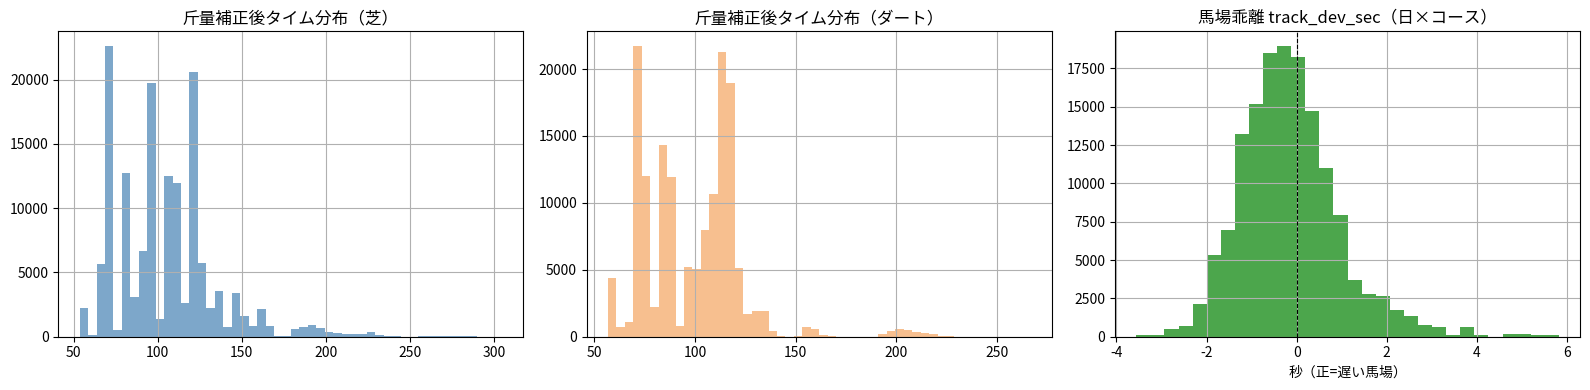

完了！


In [28]:
# ── 保存 ───────────────────────────────────────────────────────────────
SAVE_COLS = [
    'race_id', 'date', 'year', 'venue', 'venue_code', 'surface', 'distance',
    'distance_band', 'direction', 'grade', 'race_class', 'track_condition', 'track_cat',
    'weather', 'field_size',
    'horse_id', 'horse_number', 'sex', 'age_num', 'jockey_weight_num',
    'finish_pos', 'finish_time_raw_sec', 'finish_time_sec', 'adjusted_time_sec', 'last_3f',
    'front_split_sec', 'split_point_m', 'race_t2nd_sec', 'par_front_split_sec',
    'class_group', 'par_2nd_adj_sec', 'race_track_dev_sec', 'track_dev_sec',
    'tsi_raw', 'weight_dev', 'dist_scale', 'weight_sec_per_kg', 'delta_weight_sec',
    'time_z',
]
save_cols = [c for c in SAVE_COLS if c in df_clean.columns]
df_save = df_clean[save_cols].copy()

path_out = OUTPUT_DIR / 'megu_dataset.parquet'
df_save.to_parquet(path_out, index=False)
print(f'保存完了: {path_out}  shape={df_save.shape}')

par_split_full.to_parquet(OUTPUT_DIR / 'par_splits.parquet', index=False)
print(f'par_splits 保存完了: {OUTPUT_DIR / "par_splits.parquet"}')

# 分布確認プロット（斤量補正後タイム）
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, surf in zip(axes, ['芝', 'ダート', '芝']):
    sub = df_save[df_save['surface'] == surf]
    if surf == '芝' and ax == axes[2]:
        sub['track_dev_sec'].dropna().hist(bins=30, ax=ax, color='green', alpha=0.7)
        ax.set_title('馬場乖離 track_dev_sec（日×コース）')
        ax.set_xlabel('秒（正=遅い馬場）')
        ax.axvline(0, color='k', ls='--', lw=0.8)
    elif surf == '芝':
        sub['finish_time_sec'].hist(bins=50, ax=ax, color='steelblue', alpha=0.7)
        ax.set_title('斤量補正後タイム分布（芝）')
    else:
        sub['finish_time_sec'].hist(bins=50, ax=ax, color='sandybrown', alpha=0.7)
        ax.set_title('斤量補正後タイム分布（ダート）')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'data_distribution.png', dpi=80)
plt.show()
print('完了！')

# ── 分布概要 HTML（このセル直下に表示）────────────────────────────────────
from nb_viz import load_build_script, display_interactive_html

_nb01_viz = load_build_script('build_nb01_viz_html')
_overview_html = OUTPUT_DIR / 'dataset_overview.html'
_nb01_viz.write_dataset_overview_html(df_save, _overview_html)
display_interactive_html(_overview_html, height=520, title='megu_dataset 分布概要')
